# Environment Setup & Dependencies

In [15]:
import warnings
warnings.filterwarnings('ignore')

import keras
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [16]:
(xtrain,ytrain),(xtest,ytest)=keras.datasets.mnist.load_data()

In [17]:
xtrain.shape

(60000, 28, 28)

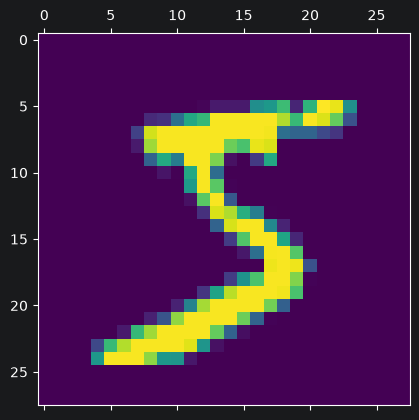

In [18]:
plt.matshow(xtrain[0])

# Data Preprocessing & Normalization

In [19]:
#scaling
xtrain=xtrain/255
xtest=xtest/255

#reshaping
xtrain=xtrain.reshape(-1,784)
xtest=xtest.reshape(-1,784)

In [20]:
xtrain[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

# Model Training

In [21]:
model=keras.Sequential()
model.add(Dense(64,activation='relu',input_dim=784)) #input
model.add(Dense(64,activation='relu')) #processing/hidden
model.add(Dense(10,activation='softmax')) #output

#dense - simple layers of neurons

In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'] #classification - accuracy , for regression - mae...
)

In [23]:
model.fit(xtrain,ytrain,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 933us/step - accuracy: 0.9203 - loss: 0.2709
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 898us/step - accuracy: 0.9615 - loss: 0.1285
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 892us/step - accuracy: 0.9708 - loss: 0.0939
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 896us/step - accuracy: 0.9764 - loss: 0.0732
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 923us/step - accuracy: 0.9811 - loss: 0.0597


# Model Evaluation

In [24]:
prediction=model.predict(xtest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 685us/step


In [25]:
print(np.argmax(prediction[0]))

7


In [26]:
print(ytest[0])

7


In [27]:
# Evaluate test accuracy
test_loss, test_acc = model.evaluate(xtest, ytest, verbose=0)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Accuracy: 97.27%


# Saving the Model

In [28]:
import os
os.makedirs("models", exist_ok=True)
model.save("models/mnist_model.keras")
print("Model saved to models/mnist_model.keras")

Model saved to models/mnist_model.keras
